# Churn SaaS — pipeline de données

Estimer la probabilité de résiliation d'un client à l'échéance, à partir de
`docs/churn_saas_complet.csv` (5035 lignes, 28 % de churn).

**Prérequis** : `docker compose up -d` — PostgreSQL sur le port 5432, pgAdmin sur
http://localhost:5050.

## 🥉🥈🥇 Ingestion complète

Lance les trois couches à la suite : `docs/*.csv` → 🥉 bronze → 🥈 silver →
🥇 gold. Chaque couche est intégralement rechargée, l'exécution est donc
rejouable sans créer de doublons.

In [20]:
from ml_churn.ingestion.scripts.ingest_all import ingest_all

lignes_ingestion = ingest_all()


🥉  BRONZE
catalogue_plans.csv : 4 lignes lues
bronze.catalogue_bronze : 4 lignes inserees

churn_saas_complet.csv : 5035 lignes lues
bronze.churn_saas_complet_bronze : 5035 lignes inserees

churn_saas_echantillon.csv : 50 lignes lues
bronze.churn_saas_echantillon_bronze : 50 lignes inserees


TOTAL :
      - bronze.catalogue_bronze : 4 lignes
      - bronze.churn_saas_complet_bronze : 5035 lignes
      - bronze.churn_saas_echantillon_bronze : 50 lignes

🥈  SILVER
bronze.catalogue_bronze : 4 lignes lues

[STANDARDISATION PLAN] : 4 valeurs -> 4 valeurs

[TYPAGE CATALOGUE] : 4 valeurs -> 4 valeurs

silver.catalogue_silver : 4 lignes inserees

bronze.churn_saas_complet_bronze : 5035 lignes lues

[DEDUPLICATION CLIENT_ID] : 5035 lignes -> 5000 lignes

[STANDARDISATION DATE_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION JOUR_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION SECTEUR] : 4750 valeurs -> 4750 valeurs
[STANDARDISATION PAYS] : 4800 valeurs -> 4800 valeu

## 1. Exploration des données brutes

Deux types de graphiques construits directement sur le CSV, avant toute
ingestion. Les valeurs sont normalisées à la volée — le CSV mélange les casses
(`TPE`, `tpe`, `" TPE "`) et les unités (`20.0%`, `3.1 h`, `280.62 €`).

**Histogrammes** — répartition des clients par secteur, pays, taille
d'entreprise et plan, puis distribution des variables d'usage (ancienneté,
CSAT, délai de réponse du support, revenu mensuel…).

**Boîtes à moustaches** — complémentaires : là où l'histogramme montre la forme
de la distribution, le boxplot isole individuellement chaque point au-delà de
1,5 × IQR, même s'il n'y en a qu'un sur 5000. Les variables très asymétriques
sont tracées en échelle logarithmique ; en linéaire, le critère IQR classe
toute la traîne en valeurs extrêmes et écrase la boîte.

Les PNG sont exportés dans `src/visualization/graphs/<type>/<préfixe>_<donnée>.png`.

In [22]:
import sys

sys.path.insert(0, "src")  # src/visualization n'est pas un package installe
from visualization.scripts.plot_all import plot_all

graphiques = plot_all()

graphs/ vide : 43 graphiques supprimes

HISTOGRAMMES
churn_saas_complet.csv : 5035 lignes lues


/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/plot_histograms.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/plot_histograms.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/plot_histograms.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/plot_histograms.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/plot_histograms.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/plot_histograms.py:287: UserWarning: Figure

  export : src/visualization/graphs/date_souscription/histo_date_souscription.png
  export : src/visualization/graphs/jour_souscription/histo_jour_souscription.png
  export : src/visualization/graphs/secteur/histo_secteur.png
  export : src/visualization/graphs/pays/histo_pays.png
  export : src/visualization/graphs/taille_entreprise/histo_taille_entreprise.png
  export : src/visualization/graphs/plan/histo_plan.png
  export : src/visualization/graphs/anciennete_mois/histo_anciennete_mois.png
  export : src/visualization/graphs/csat/histo_csat.png
  export : src/visualization/graphs/retards_paiement_12m/histo_retards_paiement_12m.png
  export : src/visualization/graphs/nb_integrations/histo_nb_integrations.png
  export : src/visualization/graphs/tickets_support_90j/histo_tickets_support_90j.png
  export : src/visualization/graphs/sieges_souscrits/histo_sieges_souscrits.png
  export : src/visualization/graphs/utilisateurs_actifs/histo_utilisateurs_actifs.png
  export : src/visualization

/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  valeur_vie_client_eur           719 points hors moustaches (log)
  heures_usage_30j                321 points hors moustaches (log)
  derniere_connexion_jours        806 points hors moustaches (log)
  anciennete_mois                   7 points hors moustaches (lineaire)
  taux_adoption_pct                 0 points hors moustaches (lineaire)


...

/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  retards_paiement_12m            422 points hors moustaches (lineaire)
  sante_compte_fin_periode          0 points hors moustaches (lineaire)

BOITES A MOUSTACHES GROUPEES
churn_saas_complet.csv : 5035 lignes lues
  tickets_support_90j        par csat | correlation -0.576 | medianes 1:6 2:4 3:3 4:1 5:0
  delai_reponse_support_h    par csat | correlation -0.342 | medianes 1:16.6 2:14.9 3:12.2 4:9.7 5:6.9

TAUX DE CHURN PAR TRANCHE
churn_saas_complet.csv : 5035 lignes lues


/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  delai_reponse_support_h    0-6h:17.5%(n=1237) 6-12h:22.1%(n=1337) 12-24h:34.5%(n=1355) 24h+:48.0%(n=604)
  tickets_support_90j        0:15.5%(n=1319) 1-2:22.7%(n=1586) 3-5:34.0%(n=1501) 6-8:49.2%(n=504) 9+:70.4%(n=125)
  retards_paiement_12m       0:18.9%(n=2822) 1:31.9%(n=1029) 2:44.6%(n=511) 3+:62.1%(n=422)
  taille_entreprise          TPE:31.8%(n=1691) PME:27.7%(n=2081) ETI:23.4%(n=897) GE:24.3%(n=366)

TAUX DE CHURN PAR VALEUR
churn_saas_complet.csv : 5035 lignes lues
  taux_fonctionnalites       53 valeurs distinctes | tendance -0.80 pt par unite

43 graphiques generes


/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/avallet/machine-learning/ml-churn/src/visualization/scripts/common.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 🥉 2. Ingestion — couche bronze

Les trois CSV de `docs/` sont copiés **tels quels** dans le schéma `bronze` :
toutes les colonnes métier en `TEXT`, aucune conversion ni nettoyage. Chaque ligne
conserve son origine (`_source_file`, `_source_line`, `_ingested_at`).

Les tables sont vidées puis rechargées : relancer la cellule ne crée pas de
doublons. Le log compare les lignes lues dans le CSV à celles réellement insérées
en base, et signale tout écart.

In [ ]:
from ml_churn.ingestion.scripts.ingest_bronze import ingest_bronze

lignes_bronze = ingest_bronze()

## 🥈 3. Ingestion — couche silver

`bronze.churn_saas_complet_bronze` → `silver.churn_saas_silver`, en onze actions
successives :

1. **Déduplication** sur `client_id`
2. **Standardisation** de huit colonnes : dates ramenées au format `AAAA-MM-JJ`,
   pays en codes ISO, plans en `PRO`/`BUS`/`STR`/`ENT`, casse et espaces harmonisés
3. **Règles métier** : toute ligne hors bornes est supprimée
4. **Typage** : `date`, `integer` et `numeric` selon la colonne

In [ ]:
from ml_churn.ingestion.scripts.ingest_silver import ingest_silver

lignes_silver = ingest_silver()

## 🥇 4. Ingestion — couche gold

`silver` → `gold`, pour les deux tables : `catalogue_gold` et
`churn_saas_gold`. Les tables reprennent **la structure de silver à
l'identique** (mêmes colonnes, mêmes types) — les définitions sont partagées
via les mixins de `models/colonnes.py`, il n'y a donc pas deux schémas à
maintenir.

Gold est la couche stable sur laquelle s'appuient l'analyse et la
modélisation, sans dépendre des retraitements successifs de silver.

In [ ]:
from ml_churn.ingestion.scripts.ingest_gold import ingest_gold

lignes_gold = ingest_gold()

## 5. Déséquilibre de la cible

Effectifs de chaque valeur de `churn` et taux de résiliation, lus dans
`gold.churn_saas_gold`. Le code est dans `src/ml_churn/training/`.

Ce déséquilibre conditionne le choix des métriques : un modèle qui prédirait
« personne ne résilie » aurait déjà une exactitude égale à la part de clients
actifs.

In [ ]:
from ml_churn.training.classification.analyze_target import analyze_target

repartition_cible = analyze_target()

## 6. Classification — baseline (régression logistique)

**Recherche du seuil.** Les 11 seuils de 0,0 à 1,0 (pas de 0,1) testés sur le modele pour évaluer lequel correspond le plus à notre besoin

Explication des features avec SHAP :

Pour explorer les runs et la matrice de confusion enregistrée :

| # | Feature | Hypothétisé | Fortes valeurs | Faibles valeurs |
|---|---------|:-----------:|:--------------:|:---------------:|
| 1 | nb_integrations | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 2 | anciennete_mois | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 3 | derniere_connexion_jours | | ⬆️⬆️⬆️ | ⬇️⬇️ |
| 4 | tickets_support_90j | ✅ | ⬆️⬆️⬆️ | ⬇️⬇️⬇️ |
| 5 | csat | ✅ | ⬇️⬇️ | ⬆️⬆️ |
| 6 | retards_paiement_12m | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 7 | taux_adoption_pct | | ⬇️⬇️ | ⬆️⬆️ |
| 8 | delai_reponse_support_h | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 9 | plan_str | | ⬆️⬆️ | ⬇️ |
| 10 | revenu_mensuel_recurrent_eur | | ⬆️⬆️ | ⬇️ |
| 11 | utilisateurs_actifs | ✅ | ⬇️⬇️ | ⬆️ |
| 12 | fonctionnalites_utilisees | ✅ | ⬇️⬇️ | ⬆️ |
| 13 | plan_ent | | ⬇️⬇️⬇️ | ⬆️ |
| 14 | couleur_theme_interface_v | | ⬇️⬇️ | ⬆️ |
| 15 | taille_entreprise_pme | ✅ | ⬇️ | ⬆️ |
| 16 | heures_usage_30j | | ⬇️ | ⬆️ |
| 17 | niveau_anciennete_ancien | | ⬆️ | ⬇️ |
| 18 | secteur_fi | | ⬇️⬇️ | ⬆️ |
| 19 | taux_fonctionnalites | | ⬆️ | ⬇️ |
| 20 | niveau_anciennete_recent | | ⬇️⬇️ | ⬆️ |

```bash
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

In [ ]:
from ml_churn.training.classification.baseline.classification_baseline_tuning import (
    tune_baseline_threshold,
)

resultat_tuning = tune_baseline_threshold()

**Entraînement et sauvegarde.** Le modèle est évalué au seuil retenu, puis
enregistré dans `artifacts/baseline/<date>/` avec ses métadonnées et les trois
extraits gold (train / validation / test). Remplace `SEUIL` par une valeur fixe
pour comparer les arbitrages : un seuil bas détecte plus de churners au prix de
fausses alertes, un seuil haut fait l'inverse.

Le seuil retenu est de 0.5 (recall = 0.8 / FPR = 0.19)

**Explication (SHAP).** Deux lectures des mêmes contributions, mesurées sur le
jeu de test :

| Graphique | Ce qu'il montre |
|---|---|
| **Bar plot** | Moyenne des \|SHAP\| par feature : le classement d'importance, sans le sens de l'effet |
| **Summary plot** | Un point par client : position = effet sur la prédiction (droite = pousse vers le churn), couleur = valeur de la feature (rouge = élevée) |

In [ ]:
from ml_churn.training.classification.baseline.classification_baseline_training import (
    train_classification_baseline,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

SEUIL = resultat_tuning.seuil  # ou une valeur fixee a la main

resultat_baseline = train_classification_baseline(seuil=SEUIL)

# Explication sur le jeu de test : ce que le modele a appris se juge sur des
# lignes qu'il n'a pas vues. Les memes figures sont attachees aux runs MLflow
# par la recherche de seuil.
display_figure(
    shap_bar_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — importance globale (seuil {SEUIL:.2f})",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — effet par client (seuil {SEUIL:.2f})",
    )
)

## 7. Classification — modèle final (XGBoost)

Même cible, même découpage et mêmes exclusions que la baseline : les deux
modèles restent comparables. Ce qui change tient au modèle — la régression
logistique suppose un effet linéaire de chaque feature, XGBoost enchaîne des
arbres qui capturent seuils et interactions.

`scale_pos_weight` remplace le `class_weight="balanced"` de la baseline : le
gradient des churners est multiplié par 2.57, le rapport entre les deux classes.

La cellule enchaîne deux étapes : **recherche** sur les neuf hyperparamètres
suivants plus le seuil de décision, puis **réentraînement** avec les valeurs
retenues et mesure sur le jeu de test tenu à l'écart jusque-là — c'est ce
modèle qui est versionné dans `artifacts/` — puis les deux lectures **SHAP**
des contributions, comme pour la baseline. Les valeurs viennent ici de
`TreeExplainer`, qui parcourt les arbres au lieu de supposer un effet
linéaire.

Contrairement à la baseline où seul le seuil variait, chaque essai de la
recherche réentraîne un modèle.

| Hyperparamètre | Plage explorée | Rôle |
|---|---|---|
| `n_estimators` | 100 → 800 | Nombre d'arbres |
| `max_depth` | 2 → 8 | Profondeur maximale d'un arbre |
| `learning_rate` | 0.01 → 0.3 | Pas d'apprentissage entre deux arbres |
| `subsample` | 0.6 → 1.0 | Part des lignes tirées par arbre |
| `colsample_bytree` | 0.4 → 1.0 | Part des colonnes tirées par arbre |
| `min_child_weight` | 1 → 20 | Poids minimal d'une feuille |
| `gamma` | 0.0 → 5.0 | Gain minimal exigé pour un découpage |
| `reg_alpha` | 1e-8 → 10 | Pénalité L1 sur les poids des feuilles |
| `reg_lambda` | 1e-8 → 10 | Pénalité L2 sur les poids des feuilles |
| `seuil` | 0.1 → 0.9 | Probabilité à partir de laquelle on alerte |

Les Hyperparamètres finaux et le seuil sont les suivants :


| Hyperparamètre | Valeur |
|---|---:|
| `seuil` | 0.45 |
| `n_estimators` | 550 |
| `max_depth` | 3 |
| `learning_rate` | 0.01 |
| `subsample` | 0.98 |
| `colsample_bytree` | 0.98 |
| `min_child_weight` | 17 |
| `gamma` | 1.52 |
| `reg_alpha` | 0.00 |
| `reg_lambda` | 0.01 |

Performances observées sur le test set :

| Métrique | Valeur |
|---|---:|
| accuracy | 0.79 |
| recall | 0.83 |
| false_positive_rate | 0.23 |
| precision | 0.59 |
| auc | 0.87 |

Conclusion : le recall est légérement meilleur que le modele baseline et le FPR a légérement augmenté.

[RECHERCHE] hyperparametres XGBoost, objectif 'f1', 30 essais
  train 3000 / validation 1000 / test 1000  (64 features, scale_pos_weight 2.57)

    essai    score   seuil   recall  precision     auc
     1/30     0.59    0.70     0.50       0.71    0.86  <- meilleur
     2/30     0.65    0.30     0.79       0.55    0.85  <- meilleur
     3/30     0.54    0.10     0.99       0.38    0.88
     4/30     0.68    0.45     0.81       0.59    0.88  <- meilleur
     5/30     0.56    0.25     0.97       0.39    0.88
     6/30     0.64    0.35     0.70       0.59    0.85
     7/30     0.49    0.90     0.35       0.82    0.86
     8/30     0.57    0.15     0.98       0.40    0.88
     9/30     0.67    0.50     0.73       0.62    0.87
    10/30     0.60    0.15     0.93       0.44    0.86
    11/30     0.67    0.55     0.72       0.63    0.87
    12/30     0.68    0.55     0.73       0.63    0.87
    13/30     0.67    0.50     0.75       0.61    0.87
    14/30     0.66    0.65     0.63       0.70 

2026/09/22 17:32:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/avallet/machine-learning/ml-churn
/Users/avallet/machine-learning/ml-churn/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/avallet/machine-learning/ml-churn/.venv/lib/python3.13/site


[HYPERPARAMETRES RETENUS] f1 = 0.68 en validation
  seuil 0.45
  n_estimators         550
  max_depth            3
  learning_rate        0.01
  subsample            0.98
  colsample_bytree     0.98
  min_child_weight     17
  gamma                1.52
  reg_alpha            0.00
  reg_lambda           0.01

[PERFORMANCE] sur le jeu de test, au seuil retenu
  accuracy              0.79
  recall                0.83
  false_positive_rate   0.23
  precision             0.59
  auc                   0.87

[MEILLEURS ESSAIS] les 5 premiers
    essai    score   seuil   recall  precision     auc
        4     0.68    0.45     0.81       0.59    0.88
       25     0.68    0.50     0.77       0.62    0.88
       24     0.68    0.55     0.73       0.64    0.88
       26     0.68    0.45     0.81       0.59    0.88
       12     0.68    0.55     0.73       0.63    0.87

  runs enregistres dans /Users/avallet/machine-learning/ml-churn/mlflow.db (uv run mlflow ui)
[ENTRAINEMENT] XGBoost sur 3000 li

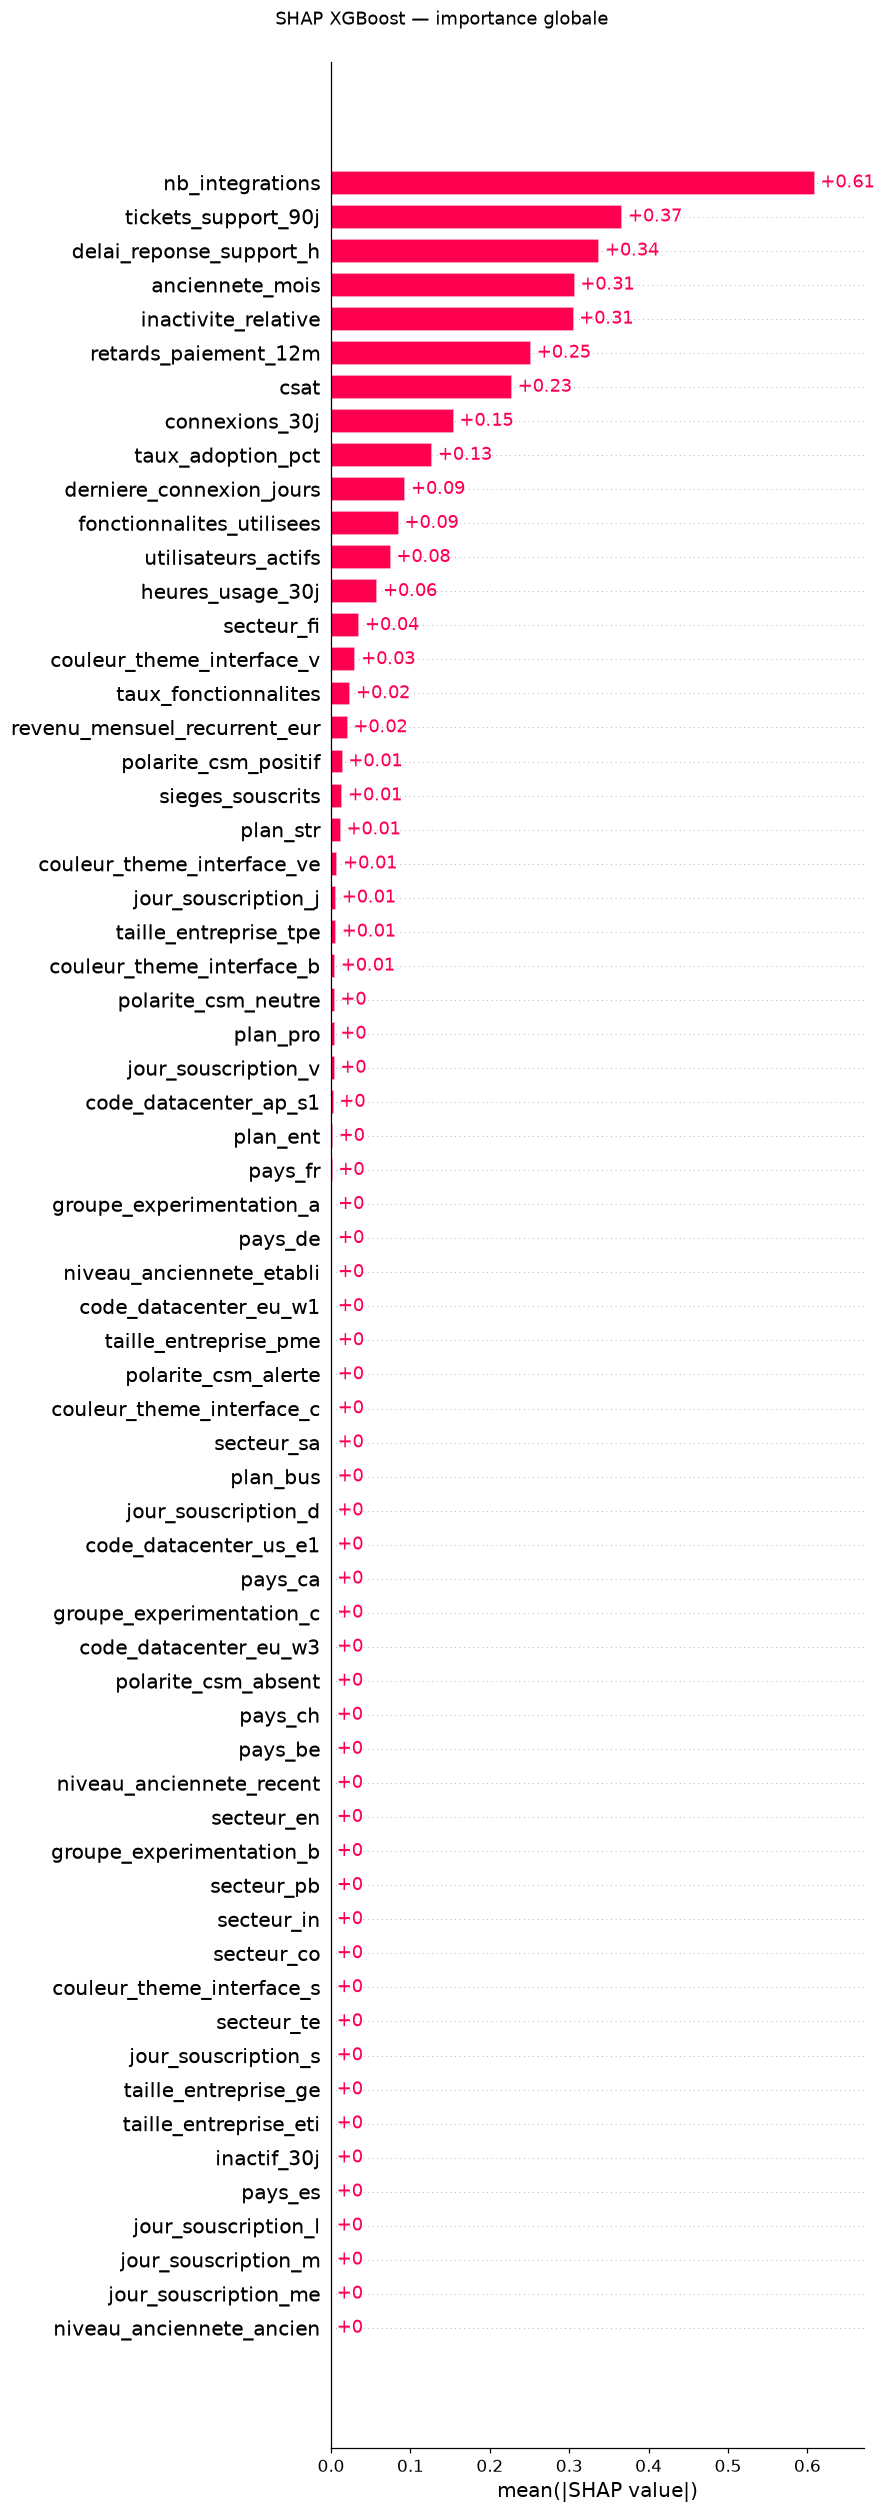

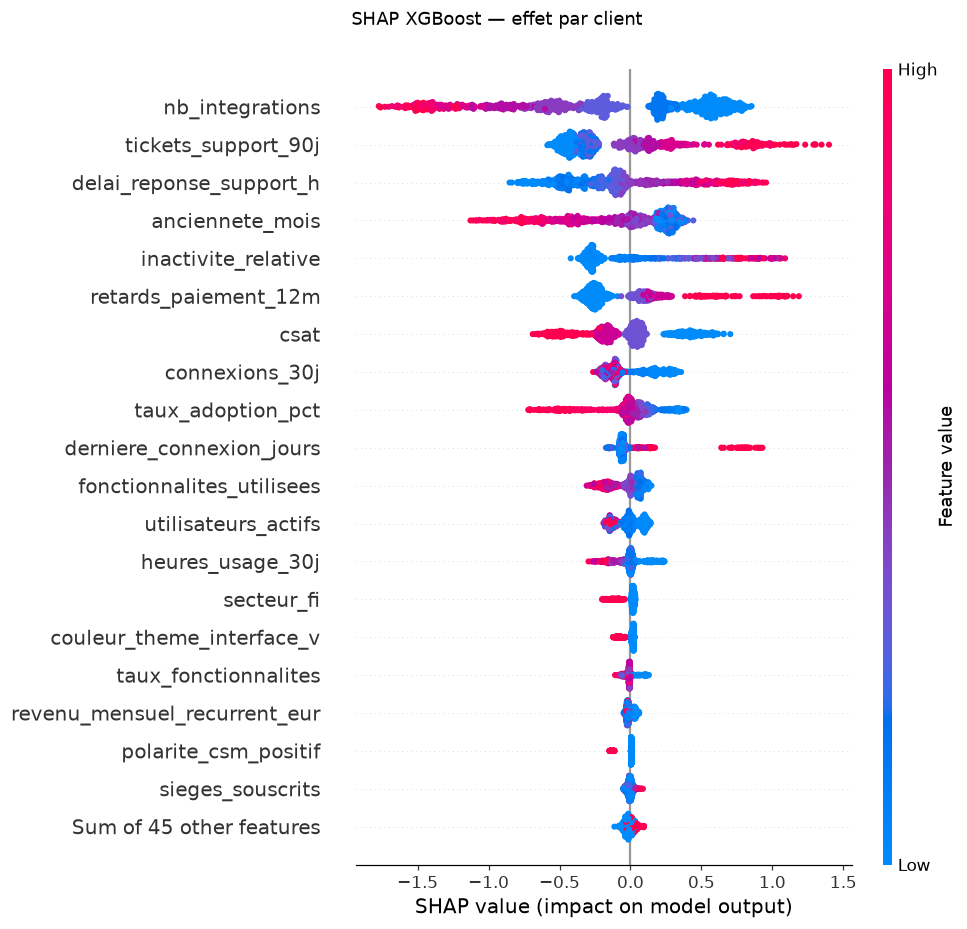

In [10]:
from ml_churn.training.classification.final.classification_xgboost_training import (
    train_classification_xgboost,
)
from ml_churn.training.classification.final.classification_xgboost_tuning import (
    tune_xgboost,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

# 1. Recherche des hyperparametres : un modele reentraine par essai.
resultat_tuning_xgboost = tune_xgboost(n_essais=30)

# 2. Reentrainement avec les hyperparametres retenus, puis mesure sur le jeu de
# test tenu a l'ecart. C'est ce modele qui est enregistre dans artifacts/.
resultat_xgboost = train_classification_xgboost(
    seuil=resultat_tuning_xgboost.seuil,
    hyperparametres=resultat_tuning_xgboost.hyperparametres,
)

# 3. Explication du modele sur le jeu de test.
display_figure(
    shap_bar_figure(
        resultat_xgboost.model,
        resultat_xgboost.X_test,
        titre="SHAP XGBoost — importance globale",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_xgboost.model,
        resultat_xgboost.X_test,
        titre="SHAP XGBoost — effet par client",
    )
)